<h1 align="center"> Image Captioning (10 баллов) </h1>

В этом ноутбуке вы обучите сеть составлять подписи к изображениям.
![img](https://i.imgur.com/obITaMl.png)


#### План работы:

1. Использовать предобученную модель Inception v3 для преобразования изображений в векторы.

2. Добавить поверх неё LSTM.

3. Обучить модель на датасете [MSCOCO](http://cocodataset.org/#download).

### 1. Данные (0.5 балла)

In [ ]:
# Скачайте датасет по ссылке https://drive.google.com/file/d/1j3Pey7vhGA5_OYrjos-gDwv5_gm7BPBO/view?usp=sharing

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
DRIVE_PATH = "/content/drive/MyDrive/"

In [8]:
%%time
# Read Dataset
import numpy as np
import json

img_codes = np.load(DRIVE_PATH + "data/image_codes.npy")
captions = json.load(open(DRIVE_PATH + 'data/captions_tokenized.json'))

CPU times: user 313 ms, sys: 655 ms, total: 969 ms
Wall time: 1.59 s



Чтобы сэкономить ваше время, мы уже преобразовали все изображения из MSCOCO17 в векторы с помощью предобученной сети Inception_v3 из библиотеки [torchvision](https://github.com/pytorch/vision/blob/master/torchvision/models/inception.py).

Весь процесс занимает от одного дня на CPU до примерно 10 минут на трёх GPU Tesla M40. [Если хотите попробовать сделать это самостоятельно — пожалуйста.](https://gist.github.com/justheuristic/11fd01f9c12c0bf960499580d104130b).


In [9]:
print("Each image code is a 2048-unit vector [ shape: %s ]" % str(img_codes.shape))
print(img_codes[0,:10], end='\n\n')
print("For each image there are 5 reference captions, e.g.:\n")
print('\n'.join(captions[0]))

Each image code is a 2048-unit vector [ shape: (118287, 2048) ]
[0.3659946  0.2016555  0.9245725  0.57063824 0.547268   0.8275868
 0.3687277  0.12085301 0.0561931  0.49758485]

For each image there are 5 reference captions, e.g.:

people shopping in an open market for vegetables .
an open market full of people and piles of vegetables .
people are shopping at an open air produce market .
large piles of carrots and potatoes at a crowded outdoor market .
people shop for vegetables like carrots and potatoes at an open air market .


Как видно, все подписи уже токенизированы и приведены к нижнему регистру. Теперь нам нужно разделить их и добавить специальные токены, обозначающие начало и конец подписи.

In [10]:
#split descriptions into tokens
for img_i in range(len(captions)):
    for caption_i in range(len(captions[img_i])):
        sentence = captions[img_i][caption_i]
        captions[img_i][caption_i] = ["#START#"]+sentence.split(' ')+["#END#"]


In [11]:
captions[0][0]

['#START#',
 'people',
 'shopping',
 'in',
 'an',
 'open',
 'market',
 'for',
 'vegetables',
 '.',
 '#END#']

Мы не хотим, чтобы сеть на каждом шаге предсказывала вероятности для миллиона слов, поэтому нужно немного сократить словарь.

Для этого посчитайте, **сколько раз встречается каждое слово** — так мы сможем решить, какие слова оставить в словаре.

In [12]:
# Build a Vocabulary
from collections import Counter
word_counts = Counter()

# Compute word frequencies for each word in captions. See code above for data structure
for img_i in range(len(captions)):
    for caption_i in range(len(captions[img_i])):
        for token_i in range(1, len(captions[img_i][caption_i]) - 1): # Посчитаем частоту всех токенов кроме токенов начала и конца подписи
            word_counts[captions[img_i][caption_i][token_i]] += 1

In [13]:
vocab  = ['#UNK#', '#START#', '#END#', '#PAD#']
vocab += [k for k, v in word_counts.items() if v >= 5 if k not in vocab]
n_tokens = len(vocab)

assert 10000 <= n_tokens <= 10500

word_to_index = {w: i for i, w in enumerate(vocab)}

In [14]:
n_tokens

10403

In [15]:
eos_ix = word_to_index['#END#']
unk_ix = word_to_index['#UNK#']
pad_ix = word_to_index['#PAD#']

def as_matrix(sequences, max_len=None):
    """ Convert a list of tokens into a matrix with padding """
    max_len = max_len or max(map(len,sequences))

    matrix = np.zeros((len(sequences), max_len), dtype='int32') + pad_ix
    for i,seq in enumerate(sequences):
        row_ix = [word_to_index.get(word, unk_ix) for word in seq[:max_len]]
        matrix[i, :len(row_ix)] = row_ix

    return matrix

In [16]:
#try it out on several descriptions of a random image
as_matrix(captions[1337])

array([[   1,   24,  262,  140,    6,  159,   14,   24,  858,  155,   12,
           2,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   53,   18,   24,  858,  155,    2,    3,    3,
           3,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   41,   18,  903,   35,  620,  155,    2,    3,
           3,    3,    3,    3,    3,    3,    3,    3],
       [   1,   45,  115,  262,   41,   53,   18,  620, 1525,   77,   12,
           2,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   53,   18,   24,  858,  123,   58,   45,  276,
        3641,   24, 3642,   35,   45, 1128,   12,    2]], dtype=int32)

### 2. Построение нейронной сети (1.5 балла)

Как уже упоминалось, мы создадим RNN-модель для генерации текста, которая будет зависеть от векторов, полученных из CNN-части сети.

![img](https://raw.githubusercontent.com/yunjey/pytorch-tutorial/master/tutorials/03-advanced/image_captioning/png/model.png)

Во время обучения мы будем использовать уже готовые вектора-признаков, а сеть Inception добавим на этапе инференса.


In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [49]:
import torch, torch.nn as nn
import torch.nn.functional as F

In [50]:
class CaptionNet(nn.Module):
    def __init__(self, n_tokens=n_tokens, emb_size=128, lstm_units=256, cnn_feature_size=2048):
        """ A recurrent 'head' network for image captioning. See scheme above. """
        super(self.__class__, self).__init__()

        # a layer that converts conv features to
        self.cnn_to_h0 = nn.Linear(cnn_feature_size, lstm_units)
        self.cnn_to_c0 = nn.Linear(cnn_feature_size, lstm_units)

        # recurrent part, please create the layers as per scheme above.

        # create embedding for input words. Use the parameters (e.g. emb_size).
        self.emb = nn.Embedding(n_tokens, emb_size)

        # lstm: create a recurrent core of your network. Use either LSTMCell or just LSTM.
        # In the latter case (nn.LSTM), make sure batch_first=True
        self.lstm = nn.LSTM(emb_size, lstm_units, num_layers=1, batch_first=True, dropout=0.0)

        # create logits: linear layer that takes lstm hidden state as input and computes one number per token
        self.logits = nn.Linear(lstm_units, n_tokens)

    def forward(self, image_vectors, captions_ix):
        """
        Apply the network in training mode.
        :param image_vectors: torch tensor containing inception vectors. shape: [batch, cnn_feature_size]
        :param captions_ix: torch tensor containing captions as matrix. shape: [batch, word_i].
            padded with pad_ix
        :returns: logits for next token at each tick, shape: [batch, word_i, n_tokens]
        """
        initial_cell = self.cnn_to_c0(image_vectors)
        initial_hid = self.cnn_to_h0(image_vectors)

        # compute embeddings for captions_ix
        captions_emb = self.emb(captions_ix)

        # apply recurrent layer to captions_emb.
        # 1. initialize lstm state with initial_* from above
        # 2. feed it with captions. Mind the dimension order in docstring
        # 3. compute logits for next token probabilities
        # Note: if you used nn.LSTM, you can just give it (initial_cell[None], initial_hid[None]) as second arg

        # lstm_out should be lstm hidden state sequence of shape [batch, caption_length, lstm_units]
        lstm_out = self.lstm(captions_emb, (initial_hid[None], initial_cell[None]))
        #print(lstm_out[0].shape)

        # compute logits from lstm_out
        logits = self.logits(lstm_out[0])

        return logits

In [51]:
network = CaptionNet(n_tokens).to(device)

In [52]:
dummy_img_vec = torch.randn(len(captions[0]), 2048).to(device)
dummy_capt_ix = torch.tensor(as_matrix(captions[0]), dtype=torch.int64).to(device)

dummy_logits = network.forward(dummy_img_vec, dummy_capt_ix)

print('shape:', dummy_logits.shape)
assert dummy_logits.shape == (dummy_capt_ix.shape[0], dummy_capt_ix.shape[1], n_tokens)

shape: torch.Size([5, 16, 10403])


In [53]:
print(dummy_capt_ix.shape)

torch.Size([5, 16])


In [54]:
def compute_loss(network, image_vectors, captions_ix):
    """
    :param image_vectors: torch tensor containing inception vectors. shape: [batch, cnn_feature_size]
    :param captions_ix: torch tensor containing captions as matrix. shape: [batch, word_i].
        padded with pad_ix
    :returns: scalar crossentropy loss (neg llh) loss for next captions_ix given previous ones
    """
    image_vectors = image_vectors.to(device)
    captions_ix = captions_ix.to(device)

    # captions for input - all except last cuz we don't know next token for last one.
    captions_ix_inp = captions_ix[:, :-1].contiguous()
    captions_ix_next = captions_ix[:, 1:].contiguous()

    # apply the network, get predictions for captions_ix_next
    logits_for_next = network.forward(image_vectors, captions_ix_inp)


    # compute the loss function between logits_for_next and captions_ix_next
    # Use the mask, Luke: make sure that predicting next tokens after EOS do not contribute to loss
    # you can do that either by multiplying elementwise loss by (captions_ix_next != pad_ix)
    # or by using ignore_index in some losses.
    loss_fn = nn.CrossEntropyLoss(ignore_index=pad_ix)
    loss = loss_fn(logits_for_next.view(-1, n_tokens), captions_ix_next.view(-1))

    return loss

In [55]:
dummy_loss = compute_loss(network, dummy_img_vec, dummy_capt_ix)

assert dummy_loss.shape == torch.Size([]), 'loss must be scalar'
assert dummy_loss.data.cpu().numpy() > 0, "did you forget the 'negative' part of negative log-likelihood"

dummy_loss.backward()

assert all(param.grad is not None for param in network.parameters()), \
        'loss should depend differentiably on all neural network weights'


Добавьте ~~adam~~ ваш любимы оптимизатор для обучения.

In [56]:
optimizer = torch.optim.Adam(network.parameters(), lr=3e-4)

### 3. Обучение (5 баллов)

* Сначала реализуйте генератор батчей.
* Затем обучите сеть как обычно.

In [57]:
from sklearn.model_selection import train_test_split
#captions = np.array(captions)
train_img_codes, val_img_codes, train_captions, val_captions = train_test_split(img_codes, captions,
                                                                                test_size=0.1,
                                                                                random_state=42)

In [58]:
from random import choice

def generate_batch(img_codes, captions, batch_size, max_caption_len=None):

    #sample random numbers for image/caption indicies
    random_image_ix = np.random.randint(0, len(img_codes), size=batch_size)

    #get images
    batch_images = img_codes[random_image_ix]

    #5-7 captions for each image
    captions_for_batch_images = [captions[i] for i in random_image_ix]
    #captions_for_batch_images = captions[random_image_ix]

    #pick one from a set of captions for each image
    batch_captions = list(map(choice,captions_for_batch_images))

    #convert to matrix
    batch_captions_ix = as_matrix(batch_captions,max_len=max_caption_len)

    return torch.tensor(batch_images, dtype=torch.float32), torch.tensor(batch_captions_ix, dtype=torch.int64)


In [59]:
generate_batch(img_codes,captions,3)

(tensor([[1.2061, 0.2126, 0.7439,  ..., 0.0789, 1.1967, 0.4030],
         [0.0133, 0.8090, 0.0762,  ..., 0.5652, 1.2383, 0.1202],
         [0.3968, 0.1549, 0.3468,  ..., 0.0000, 1.2136, 0.1233]]),
 tensor([[   1, 2897,   24,  106,   14,    4,  123,   24,   57,  286,   24,  981,
             6,   73,  785,   12,    2],
         [   1,   24,   21,   47,  291,   14,  182,   35,   24,   71,   12,    2,
             3,    3,    3,    3,    3],
         [   1,   24,  281,  542,  211,  624,  117,  726,   24,  578,   12,    2,
             3,    3,    3,    3,    3]]))

Обучайте модель на мини-батчах, как обычно. Периодически проверяйте качество на валидационном наборе.

#### **Советы**

* Если тренировочный лосс почти равен нулю или модель генерирует бессмысленный текст — проверьте, что вы предсказываете следующее слово, а не текущее или слово через два шага.

* Если модель создаёт плавные, но нерелевантные описания:

  * возможно, рекуррентная сеть не получает векторы изображения;

  * также это может быть следствием взрыва градиентов — попробуйте клиппинг или перезапуск обучения;

  * наконец, возможно, модель просто нужно обучить дольше.

* Кросс-энтропия — слабый показатель переобучения:

  * модель может переобучиться по валидационной кросс-энтропии, но при этом продолжать улучшать качество генерации;

  * используйте ручную оценку или автоматические метрики, такие как CIDEr или BLEU.

* Рекомендуется периодически проверять сеть с помощью блока “apply trained model” — можно остановить обучение, протестировать несколько примеров и продолжить.

* Типичные значения функции потерь: около 3–5, если усреднять по времени,
или масштабировать по длине при суммировании. Разумные подписи начинают появляться при лоссе 2.8–3.0.

In [60]:
batch_size = 100  # adjust me
n_epochs = 100  # adjust me
n_batches_per_epoch = 60  # adjust me
n_validation_batches = 12  # how many batches are used for validation after each epoch

In [61]:
from tqdm import tqdm

train_loss_list = []
val_loss_list = []

for epoch in range(n_epochs):

    train_loss=0
    network.train(True)
    for _ in tqdm(range(n_batches_per_epoch)):
        img_batch, cap_batch = generate_batch(train_img_codes, train_captions, batch_size)
        img_batch = img_batch.to(device)
        cap_batch = cap_batch.to(device)

        loss_t = compute_loss(network, img_batch, cap_batch)

        # clear old gradients; do a backward pass to get new gradients; then train with opt
        optimizer.zero_grad()
        loss_t.backward()
        optimizer.step()

        train_loss += loss_t.item()

    train_loss /= n_batches_per_epoch
    train_loss_list.append(train_loss)

    val_loss=0
    network.train(False)
    for _ in range(n_validation_batches):
        img_batch, cap_batch = generate_batch(val_img_codes, val_captions, batch_size)
        img_batch = img_batch.to(device)
        cap_batch = cap_batch.to(device)

        loss_t = compute_loss(network, img_batch, cap_batch)

        val_loss += loss_t.item()
    val_loss /= n_validation_batches
    val_loss_list.append(val_loss)

    print('\nEpoch: {}, train loss: {}, val loss: {}'.format(epoch, train_loss, val_loss))

print("Finished!")

100%|██████████| 60/60 [00:01<00:00, 51.61it/s]



Epoch: 0, train loss: 7.015590214729309, val loss: 5.126933892567952


100%|██████████| 60/60 [00:01<00:00, 59.76it/s]



Epoch: 1, train loss: 4.981667002042134, val loss: 4.855533639589946


100%|██████████| 60/60 [00:01<00:00, 54.78it/s]


...


Epoch: 97, train loss: 2.7016548832257588, val loss: 2.7498131593068442


100%|██████████| 60/60 [00:01<00:00, 52.52it/s]



Epoch: 98, train loss: 2.709217353661855, val loss: 2.7227341731389365


100%|██████████| 60/60 [00:01<00:00, 53.43it/s]


Epoch: 99, train loss: 2.730860376358032, val loss: 2.7868488828341165
Finished!


Значение функции потерь на валидаии <2.8, можно остановиться и проверить качество генерации

In [62]:
import matplotlib.pyplot as plt

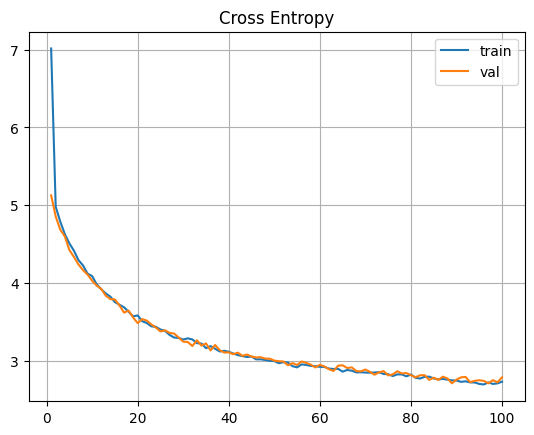

In [63]:
plt.plot(np.arange(1, n_epochs + 1), train_loss_list, label="train")
plt.plot(np.arange(1, n_epochs + 1), val_loss_list, label="val")
plt.title("Cross Entropy")
plt.legend()
plt.grid()
plt.show()

### 4. Применяем обученную модель (0.5 балла)

Теперь загрузим предобученнную Inceprion модель и посмотрим, на что способна наша модель.


In [ ]:
# from beheaded_inception3 import beheaded_inception_v3
# inception = beheaded_inception_v3().train(False)

In [64]:
from torchvision.models import inception_v3

def beheaded_inception_v3(pretrained=True):
    model = inception_v3(pretrained=pretrained)
    model.fc = nn.Identity()
    return model

inception = beheaded_inception_v3().train(False)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 175MB/s]


#### **Генерируем подписи**

Функция ниже генерирует подписи, выбирая слова на основе вероятностей, предсказанных моделью.

Реализация здесь простая, но неэффективная (её сложность квадратична по числу шагов LSTM).

In [72]:
def generate_caption(image, caption_prefix=("#START#",),
                     t=1, sample=True, max_len=100):
    assert isinstance(image, np.ndarray) and np.max(image) <= 1\
           and np.min(image) >=0 and image.shape[-1] == 3

    with torch.no_grad():
        image = torch.tensor(image.transpose([2, 0, 1]), dtype=torch.float32)

        #vectors_8x8, vectors_neck, logits = inception(image[None])
        vectors_neck = inception(image[None]).to(device)
        caption_prefix = list(caption_prefix)

        for _ in range(max_len):

            prefix_ix = as_matrix([caption_prefix])
            prefix_ix = torch.tensor(prefix_ix, dtype=torch.int64).to(device)
            next_word_logits = network.forward(vectors_neck, prefix_ix)[0, -1]
            next_word_probs = F.softmax(next_word_logits, dim=-1).data.cpu().numpy()

            assert len(next_word_probs.shape) ==1, 'probs must be one-dimensional'
            next_word_probs = next_word_probs ** t / np.sum(next_word_probs ** t) # apply temperature

            if sample:
                next_word = np.random.choice(vocab, p=next_word_probs)
            else:
                next_word = vocab[np.argmax(next_word_probs)]

            caption_prefix.append(next_word)

            if next_word == "#END#":
                break

    return caption_prefix

In [ ]:
# from matplotlib import pyplot as plt
# from scipy.misc import imresize
# %matplotlib inline

# sample image
# !wget https://pixel.nymag.com/imgs/daily/selectall/2018/02/12/12-tony-hawk.w710.h473.jpg -O data/img.jpg
# img = plt.imread('data/img.jpg')
# img = imresize(img, (299, 299)).astype('float32') / 255.

In [67]:
from matplotlib import pyplot as plt
from PIL import Image
%matplotlib inline


!wget https://pixel.nymag.com/imgs/daily/selectall/2018/02/12/12-tony-hawk.w710.h473.jpg -O data/img_test.jpg

img = Image.open('data/img_test.jpg')
img = img.resize((299, 299))
img = np.array(img).astype('float32') / 255.0

--2025-10-28 12:48:46--  https://pixel.nymag.com/imgs/daily/selectall/2018/02/12/12-tony-hawk.w710.h473.jpg
Resolving pixel.nymag.com (pixel.nymag.com)... 199.232.193.246, 199.232.197.246
Connecting to pixel.nymag.com (pixel.nymag.com)|199.232.193.246|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://pyxis.nymag.com/v1/imgs/6ac/2a6/b48d3a180f333298f5bee60ff80f4ba886-12-tony-hawk.h473.w710.jpg [following]
--2025-10-28 12:48:46--  https://pyxis.nymag.com/v1/imgs/6ac/2a6/b48d3a180f333298f5bee60ff80f4ba886-12-tony-hawk.h473.w710.jpg
Resolving pyxis.nymag.com (pyxis.nymag.com)... 199.232.193.246, 199.232.197.246
Connecting to pyxis.nymag.com (pyxis.nymag.com)|199.232.193.246|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 54731 (53K) [image/jpeg]
Saving to: ‘data/img_test.jpg’

data/img_test.jpg   100%[===================>]  53.45K  --.-KB/s    in 0.01s   

2025-10-28 12:48:47 (4.78 MB/s) - ‘data/img_test.jpg’ saved 

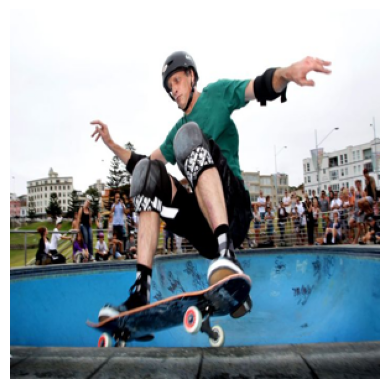

In [68]:
plt.imshow(img)
plt.axis('off')
plt.show()

In [73]:
for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

a man riding a skateboard on a skateboard .
a man riding a skateboard down a ramp .
a man riding a skateboard on a skateboard .
a man riding a skateboard on a skateboard .
a man riding a skateboard down a ramp .
a man riding a skateboard on a skateboard .
a man riding a skateboard down a ramp .
a man riding a skateboard on a skateboard .
a man riding a skateboard down a ramp .
a man riding a skateboard on a skateboard .


### 5. Demo (2.5 балла)
##### **Найдите как минимум 10 изображений для теста.**

* Серьёзно, это часть задания — подготовьте хотя бы 10 картинок для генерации подписей.

* Сначала проверьте работу модели на простых изображениях, прежде чем переходить к более сложным.

* В вашем наборе должны быть примеры как удачных, так и неудачных подписей — проявите креативность :)

* Используйте фотографии, а не анимацию, 3D или рисунки — иначе придётся переобучать CNN на аниме.

* Обратите внимание на соотношение сторон изображений.

Троллейбус горит, да и... пусть горит. У меня осталось две поездки на следующий автобус. Вон он, на подходе. Я буду дома вовремя!

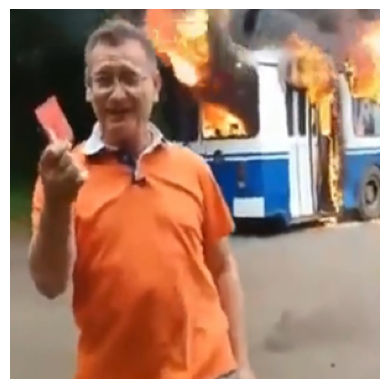

In [75]:
img = Image.open('data/img1.jpg')
img = img.resize((299, 299))
img = np.array(img).astype('float32') / 255.0

plt.imshow(img)
plt.axis('off')
plt.show()

In [76]:
for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

a man with a hat and a woman standing next to a woman .
a woman with a hat and a dog on a cell phone .
a man with a hat and a dog on a street .
a woman holding a cell phone in a field .
a man is holding a cell phone while standing in the street .
a man with a hat and a woman walking down the street .
a man with a hat and a dog on a street .
a man holding a cell phone while standing on a street .
a group of people standing around a street with a crowd of people .
a man is holding a dog in a park .


Ожидаемый результат. Предобученный inception вряд ли обучался на горящих троллейбусах, также маловероятно, что в MSCOCO17, на котором обучался декодер, присутствуют такие сюжеты.

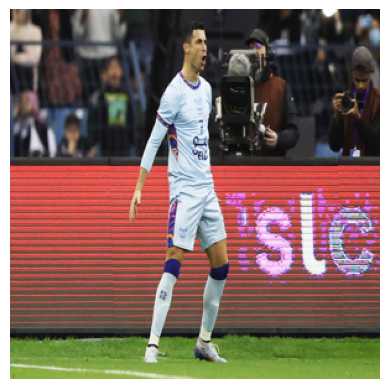

In [79]:
img = Image.open('data/img2.jpg')
img = img.resize((299, 299))
img = np.array(img).astype('float32') / 255.0

plt.imshow(img)
plt.axis('off')
plt.show()

In [80]:
for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

a tennis player is swinging a ball with a racket .
a man holding a tennis racket on a tennis court .
a man holding a tennis racket on a tennis court .
a tennis player is swinging a tennis racket .
a man in a tennis court holding a tennis racket .
a man in a tennis court holding a tennis racket .
a tennis player is hitting the ball with a racket .
a tennis player is swinging a tennis racket .
a man playing tennis on a tennis court .
a man in a tennis court holding a tennis racket .


Как ни странно, сеть не научилась определять футбол. Проблема может быть так же как в энкордере (inception не смотрел футбол), так и в декодере (MSCOCO17 не содержит изображений игры в футбол, однако, судя по всему, содержит изображения игры в теннис).

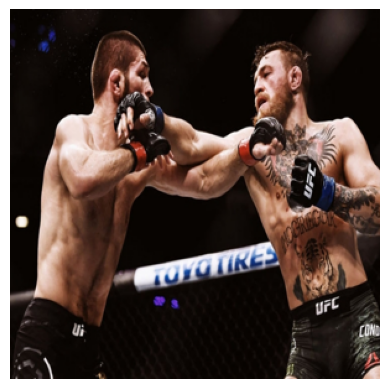

In [81]:
img = Image.open('data/img3.jpg')
img = img.resize((299, 299))
img = np.array(img).astype('float32') / 255.0

plt.imshow(img)
plt.axis('off')
plt.show()

In [82]:
for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

a man is playing a game of tennis .
a man holding a tennis racquet on a tennis court .
a man in a red shirt and a woman playing a game .
a man is holding a tennis racket and a tennis racket .
a man is holding a tennis racket and a racket .
a man in a blue shirt and a tie .
a man holding a tennis racket and a tennis racket .
a man holding a tennis racket on a tennis court .
a man holding a tennis racket on a tennis court .
a man is holding a tennis racket on a tennis court .


Все же сеть - фанат тенниса

В таком случае, покажем сети то, что она хочет

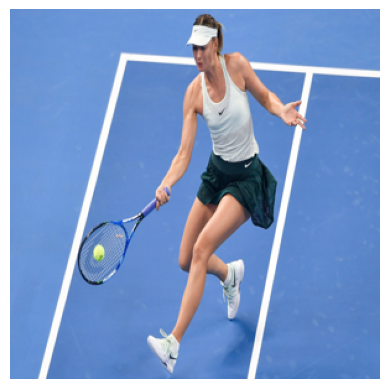

In [83]:
img = Image.open('data/img4.jpg')
img = img.resize((299, 299))
img = np.array(img).astype('float32') / 255.0

plt.imshow(img)
plt.axis('off')
plt.show()

In [84]:
for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

a man on a tennis court holding a racket .
a tennis player is hitting a ball with a racket .
a woman in a tennis court holding a tennis racket .
a woman in a tennis court holding a tennis racket .
a man playing tennis on a tennis court .
a man holding a tennis racket on a tennis court .
a tennis player is swinging a racket on a tennis court .
a woman playing tennis on a tennis court .
a tennis player is swinging a tennis racket .
a man in a tennis court holding a tennis racket .


Было бы странно увидеть здесь описания про футбол. Сеть иногда нерправильно определяет пол человека

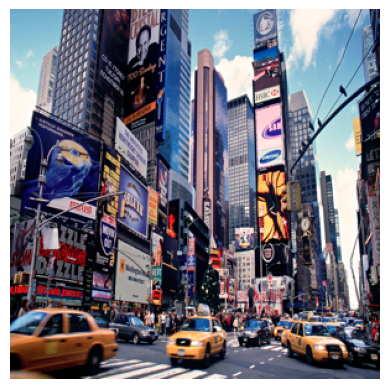

In [96]:
img = Image.open('data/img5.jpg')
img = img.resize((299, 299))
img = np.array(img).astype('float32') / 255.0

plt.imshow(img)
plt.axis('off')
plt.show()

In [97]:
for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

a street with a traffic light on a street .
a street with a street sign on the side of it .
a street with a street sign in the middle of it .
a street with a street sign on a pole
a street with a street sign on the side of the road .
a city street with a clock on top of it .
a street with a street sign and a street sign
a street with a street sign on the side of it .
a street with a street sign on the side of the street .
a street sign on a street corner with a street sign .


Сложная композиция, очень много объектов на изображении. Тем не меннее, сеть поняла, что на изображении городской сюжет

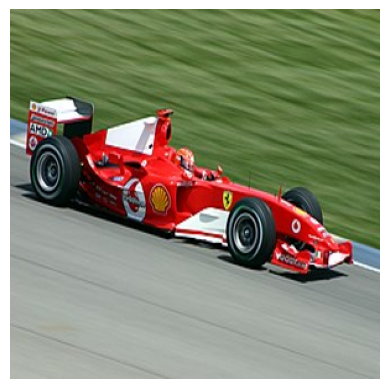

In [86]:
img = Image.open('data/img6.jpg')
img = img.resize((299, 299))
img = np.array(img).astype('float32') / 255.0

plt.imshow(img)
plt.axis('off')
plt.show()

In [87]:
for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

a red and white truck parked in a parking lot .
a red and white truck parked on a street .
a red and white truck parked next to a car .
a large red and white truck parked in a parking lot .
a red and white truck parked next to a car .
a red and white truck is parked in a parking lot .
a red and white truck parked in a parking lot .
a red and white truck parked on a road .
a red and white motorcycle is parked on the side of the road .
a red and white motorcycle parked on a street .


Здесь видно, что сеть также на сталкивалась с гоночными болидами во время обучения (довольно специфическая разновидность транспорта), но предположила, что это грузовик или мотоцикл

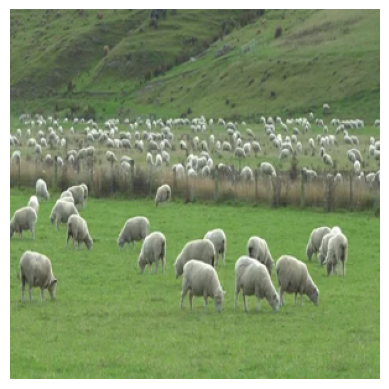

In [88]:
img = Image.open('data/img7.jpg')
img = img.resize((299, 299))
img = np.array(img).astype('float32') / 255.0

plt.imshow(img)
plt.axis('off')
plt.show()

In [89]:
for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

a herd of sheep grazing in a grassy field .
a herd of sheep grazing in a field near a fence .
a herd of sheep grazing on a lush green field .
a herd of sheep grazing in the grass in a field .
a herd of sheep grazing in a field of grass .
a herd of sheep grazing on a field next to a tree .
a herd of sheep grazing on a field of grass .
a herd of sheep grazing in a field by a fence .
a herd of sheep grazing in a field of grass .
a herd of sheep grazing in a field with trees in the background .


Точное попадание

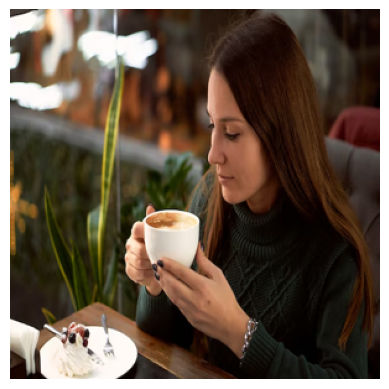

In [90]:
img = Image.open('data/img8.jpg')
img = img.resize((299, 299))
img = np.array(img).astype('float32') / 255.0

plt.imshow(img)
plt.axis('off')
plt.show()

In [91]:
for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

a woman holding a slice of pizza with a knife .
a woman eating a slice of pizza with a fork .
a woman is eating a plate of food .
a woman with a woman in a white shirt and a woman eating a pizza .
a woman with a woman eating a slice of pizza .
a woman holding a slice of cake on a plate .
a woman holding a slice of cake with a fork .
a woman holding a plate of food with a knife .
a woman holding a plate of food with a fork .
a woman is eating a slice of cake .


Сеть не распознала кофе, однако, в некоторых описаниях упомянула про торт, что очень неплохо

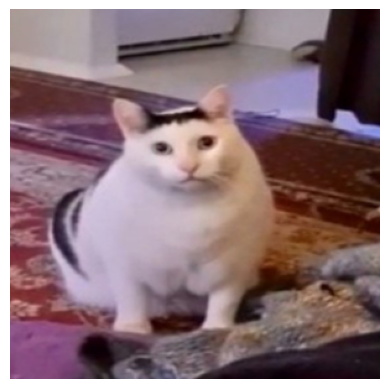

In [92]:
img = Image.open('data/img9.jpg')
img = img.resize((299, 299))
img = np.array(img).astype('float32') / 255.0

plt.imshow(img)
plt.axis('off')
plt.show()

In [93]:
for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

a cat is sitting on a table next to a laptop .
a cat is sitting on a chair in a room .
a cat sitting on a table with a cat on it .
a cat is sitting on a chair with a cat .
a cat is sitting on a table with a cat .
a cat is sitting on a wooden table .
a cat is sitting on a table with a cat .
a cat is sitting on a table with a cat .
a cat is sitting on a table with a cat .
a cat is sitting on a table with a cat .


Сидящий кот распознан очень хорошо, но окружение описано неправильно

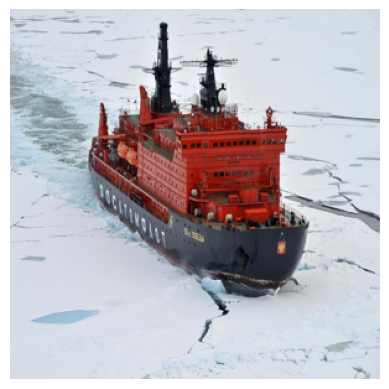

In [94]:
img = Image.open('data/img10.jpg')
img = img.resize((299, 299))
img = np.array(img).astype('float32') / 255.0

plt.imshow(img)
plt.axis('off')
plt.show()

In [95]:
for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

a large boat on a boat in the water .
a large boat is parked in the water .
a boat in a boat with a large body of water
a boat is parked in the water with a boat .
a large boat is on a beach .
a boat with a large body of water on it
a large boat is parked in the water .
a large boat is sitting on a boat .
a large boat on a boat in the water .
a boat on a beach with a boat in the background .


Вероятно сеть не видела ледоколов, что ожидаемо, но видела большие корабли


![img](https://cs7.pikabu.ru/images/big_size_comm_an/2018-09_3/1536865148163644198.gif)

> Примечание: Это задание адаптировано по материалам курса "Deep Learning" (Skoltech).
